# Análise do Dataset Housing

 **Descrição do Projeto**

Aplicação completa do processo de **Ciência de Dados** em um conjunto de dados sobre propriedades imobiliárias. Este projeto demonstra desde a exploração inicial até a modelagem preditiva.

 **Sobre o Dataset**

O dataset Housing contém informações detalhadas sobre características de casas e seus respectivos valores de venda. É um conjunto de dados clássico utilizado para fins de análise e aprendizado em regressão.

 *Objetivos*

- **Exploração e Limpeza**: Compreender a estrutura dos dados, identificar valores ausentes e aplicar técnicas de limpeza quando necessário
- **Modelagem de Regressão**: Desenvolver modelos preditivos tanto para regressão simples (uma variável) quanto múltipla (várias variáveis)
- **Avaliação e Comparação**: Avaliar o desempenho dos modelos utilizando métricas como R², RMSE e outras, identificando o melhor modelo

---

In [20]:
#Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [21]:
df = pd.read_csv('housing.csv')
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [22]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   price             545 non-null    int64
 1   area              545 non-null    int64
 2   bedrooms          545 non-null    int64
 3   bathrooms         545 non-null    int64
 4   stories           545 non-null    int64
 5   mainroad          545 non-null    str  
 6   guestroom         545 non-null    str  
 7   basement          545 non-null    str  
 8   hotwaterheating   545 non-null    str  
 9   airconditioning   545 non-null    str  
 10  parking           545 non-null    int64
 11  prefarea          545 non-null    str  
 12  furnishingstatus  545 non-null    str  
dtypes: int64(6), str(7)
memory usage: 55.5 KB


In [23]:
#transformando variáveis categóricas em numéricas
df[['mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea']] = df[['mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea']].replace({'yes': 1, 'no': 0})
df['furnishingstatus'] =df['furnishingstatus'].replace({'furnished': 1, 'semi-furnished': 0, 'unfurnished': -1})
df.head(10)
    

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,1
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,1
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,0
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,1
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,1
5,10850000,7500,3,3,1,1,0,1,0,1,2,1,0
6,10150000,8580,4,3,4,1,0,0,0,1,2,1,0
7,10150000,16200,5,3,2,1,0,0,0,0,0,0,-1
8,9870000,8100,4,1,2,1,1,1,0,1,2,1,1
9,9800000,5750,3,2,4,1,1,0,0,1,1,1,-1


In [24]:
#estatisticas descritivas do dataset
df.describe().round(2)

,price,area,bedrooms,bathrooms,stories,parking
count,545.00,545.00,545.00,545.00,545.00,545.00
mean,4766729.25,5150.54,2.97,1.29,1.81,0.69
std,1870439.62,2170.14,0.74,0.50,0.87,0.86
min,1750000.00,1650.00,1.00,1.00,1.00,0.00
25%,3430000.00,3600.00,2.00,1.00,1.00,0.00
50%,4340000.00,4600.00,3.00,1.00,2.00,0.00
75%,5740000.00,6360.00,3.00,2.00,2.00,1.00
max,13300000.00,16200.00,6.00,4.00,4.00,3.00


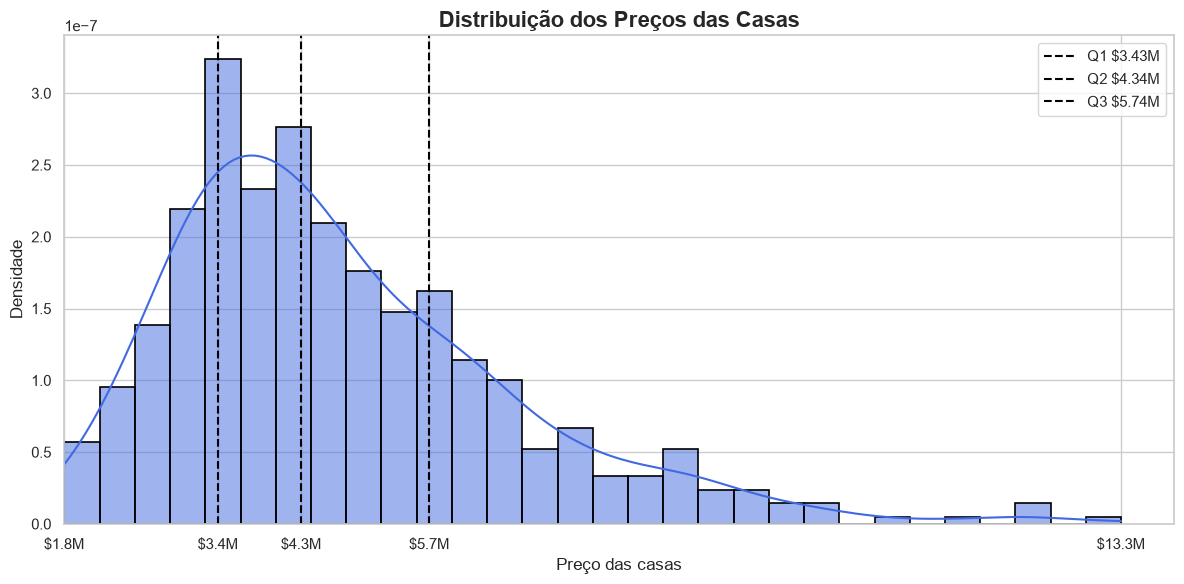

In [37]:
from matplotlib.ticker import FuncFormatter
sns.set_theme(style='whitegrid')

price_data = df['price']

q1 = price_data.quantile(0.25)
q2 = price_data.quantile(0.50)
q3 = price_data.quantile(0.75)

plt.figure(figsize=(12,6))
min_price = price_data.min()
max_price = price_data.max()

sns.histplot(price_data, bins=30, stat='density', color='royalblue', alpha=0.5, edgecolor='black', linewidth=1.2, kde=True)

plt.axvline(x=q1, color='black', linestyle='--', label=f'Q1 ${q1/1e6:.2f}M')
plt.axvline(x=q2, color='black', linestyle='--', label=f'Q2 ${q2/1e6:.2f}M')
plt.axvline(x=q3, color='black', linestyle='--', label=f'Q3 ${q3/1e6:.2f}M')
plt.gca().xaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f'${x/1e6:.1f}M')
)
plt.title('Distribuição dos Preços das Casas', fontsize=16, fontweight='bold')
plt.xlabel('Preço das casas', fontsize=12)
plt.ylabel('Densidade', fontsize=12)
plt.xlim(left=min_price)
plt.xticks([min_price, q1, q2, q3, max_price])

plt.legend()
plt.tight_layout()
plt.show()